In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('bhp.csv')
df.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250


In [3]:
df.price_per_sqft.describe()

count    1.320000e+04
mean     7.920337e+03
std      1.067272e+05
min      2.670000e+02
25%      4.267000e+03
50%      5.438000e+03
75%      7.317000e+03
max      1.200000e+07
Name: price_per_sqft, dtype: float64

In [4]:
min_threshold, max_threshold = df.price_per_sqft.quantile([0.001,0.999])
min_threshold, max_threshold

(1366.184, 50959.3619999996)

In [9]:
df_new = df[(df.price_per_sqft > min_threshold) & (df.price_per_sqft < max_threshold)]
df_new.price_per_sqft.describe()

count    13172.000000
mean      6663.653735
std       4141.020700
min       1379.000000
25%       4271.000000
50%       5438.000000
75%       7311.000000
max      50349.000000
Name: price_per_sqft, dtype: float64

*STEP 3*

In [13]:
sd = df_new.price_per_sqft.std()
mean = df_new.price_per_sqft.mean()


In [27]:
df_new['z_score'] = (df_new.price_per_sqft - mean) / sd
df_new.head(5)

,location,size,total_sqft,bath,price,bhk,price_per_sqft,z_score
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699,-0.715923
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615,-0.494722
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305,-0.569583
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245,-0.101099
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250,-0.582864


In [28]:
df_5 = df_new[(df_new.z_score > -4) & (df_new.z_score < 4)]
df_5.price_per_sqft.describe()

count    13047.000000
mean      6449.328045
std       3487.670005
min       1379.000000
25%       4259.000000
50%       5415.000000
75%       7222.000000
max      23214.000000
Name: price_per_sqft, dtype: float64

In [14]:
df_outlier_removed_sd = df_new[(df_new.price_per_sqft > mean-(4*sd) ) & (df_new.price_per_sqft < mean+(4*sd) )]
df_outlier_removed_sd.price_per_sqft.describe()

count    13047.000000
mean      6449.328045
std       3487.670005
min       1379.000000
25%       4259.000000
50%       5415.000000
75%       7222.000000
max      23214.000000
Name: price_per_sqft, dtype: float64

<Axes: xlabel='price_per_sqft', ylabel='Count'>

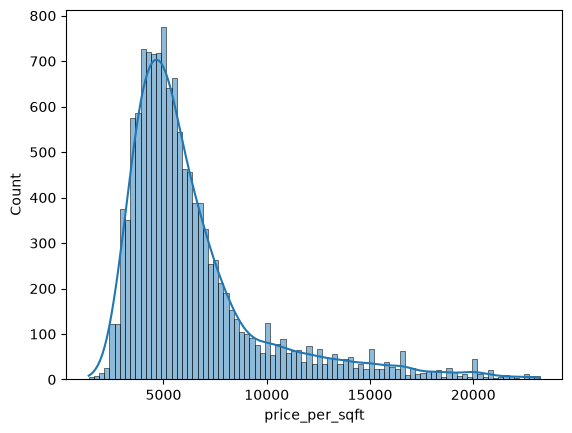

In [19]:
import seaborn as sns
sns.histplot(df_outlier_removed_sd.price_per_sqft, kde=True)